# Problem Statement
This is a **supervised regression** problem: predicting `TargetValue`, the
resale price of heavy equipment, from machine specifications (age, hours used,
category, region, etc.). The evaluation metric is RMSLE (Root Mean Squared
Log Error).

# IMPORT LIBRARIES

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# LOAD THE DATA

In [2]:
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

test_ids = test["TransactionID"]
print("Train:", train.shape, "| Test:", test.shape)

Train: (138701, 50) | Test: (15000, 49)


# EXPLORATORY DATA ANALYSIS

## Dataset Structure Check
Goal: confirm column dtypes, row count, and non-null counts 

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [4]:
train.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


In [5]:
train.columns

Index(['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
       'DataOriginCode', 'VendorPartnerID', 'ManufactureYear',
       'OperationalHoursMeter', 'UtilizationTier', 'TransactionDate',
       'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass',
       'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor',
       'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory',
       'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3',
       'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9',
       'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18',
       'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27',
       'col28', 'col29', 'col30'],
      dtype='object')

## Missing Value Analysis (Detailed %)
Goal: check what percent of each column is missing, not just the count.
If a column is almost completely empty, I should drop it instead of trying
to fix it.

In [6]:
train.isnull().sum().sort_values(ascending=False)

col19                        138635
col18                        138635
col5                         128320
col4                         128320
col27                        123742
col28                        123742
col29                        119829
col30                        119829
col13                        115296
col14                        115296
col7                         115296
col6                         115296
col9                         115296
col8                         115296
col11                        115296
col3                         109448
Forks                        109382
Spec_ReleaseSeries           105805
col1                         104915
col12                        100337
col15                         96424
DrivetrainType                89956
UtilizationTier               88226
Spec_VariantModifier          86369
col20                         67685
col25                         67685
col21                         67685
col22                       

In [7]:
missing_percent = (
    train.isnull().sum()
    / len(train)
) * 100

missing_percent = missing_percent[missing_percent > 0]

missing_percent.sort_values(
    ascending=False
)

col18                    99.952416
col19                    99.952416
col4                     92.515555
col5                     92.515555
col28                    89.214930
col27                    89.214930
col30                    86.393753
col29                    86.393753
col14                    83.125572
col11                    83.125572
col13                    83.125572
col8                     83.125572
col9                     83.125572
col6                     83.125572
col7                     83.125572
col3                     78.909309
Forks                    78.861724
Spec_ReleaseSeries       76.282795
col1                     75.641127
col12                    72.340502
col15                    69.519326
DrivetrainType           64.856057
UtilizationTier          63.608770
Spec_VariantModifier     62.269919
col21                    48.799216
col20                    48.799216
col25                    48.799216
col23                    48.797774
col24               

## Removing Columns with High Missing Values

Columns with more than 90% missing values contain very little useful information, so they are removed to reduce noise and simplify the dataset.

In [8]:
# Drop columns with more than 90% missing values
high_missing_cols = missing_percent[missing_percent > 90].index

train = train.drop(columns=high_missing_cols)
test = test.drop(columns=high_missing_cols)

print("Dropped columns:", list(high_missing_cols))
print("New train shape:", train.shape)
print("New test shape:", test.shape)

Dropped columns: ['col4', 'col5', 'col18', 'col19']
New train shape: (138701, 46)
New test shape: (15000, 45)


**Inference:** col18 and col19 are 100% empty, so I remove them. col4 and
col5 are about 92% empty, so filling them in wouldn't really help — they
have almost no real data.

## Target Variable Distribution
Goal: check the shape of `TargetValue` (skewed vs symmetric). This directly decides whether to log-transform the target before modeling.

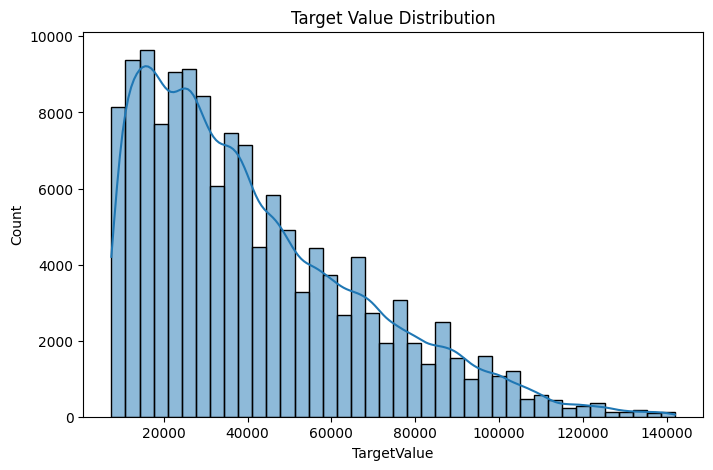

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["TargetValue"],
    bins=40,
    kde=True
)

plt.title("Target Value Distribution")

plt.show()

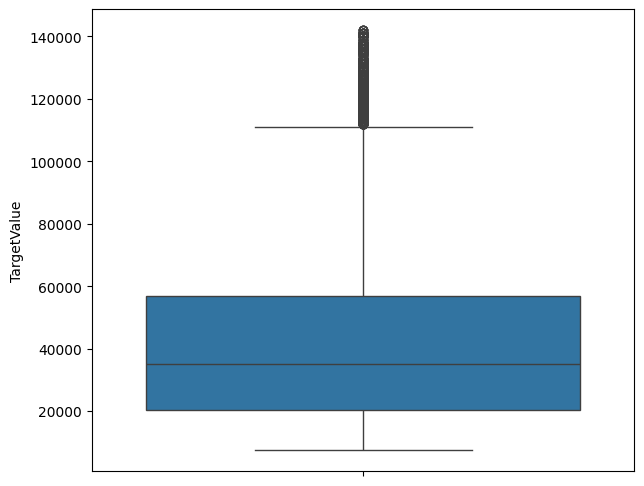

In [10]:
plt.figure(figsize=(7,6))

sns.boxplot(
    y=train["TargetValue"]
)

plt.show()

**Inference:** TargetValue is skewed — most machines are cheap, but a few
are very expensive, which pulls the shape to one side. Because of this, I
will apply a log transform to the target before training my models.

## Identify Numeric Features
Goal: separate numeric columns so a correlation heatmap can be computed (correlation is undefined for categorical/text columns).

In [11]:
numeric_cols = train.select_dtypes(
    include=["int64","float64"]
).columns

numeric_cols

Index(['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
       'ManufactureYear', 'OperationalHoursMeter'],
      dtype='object')

## Correlation Analysis
Goal: see which numeric features move together with `TargetValue` and with each other (multicollinearity check).

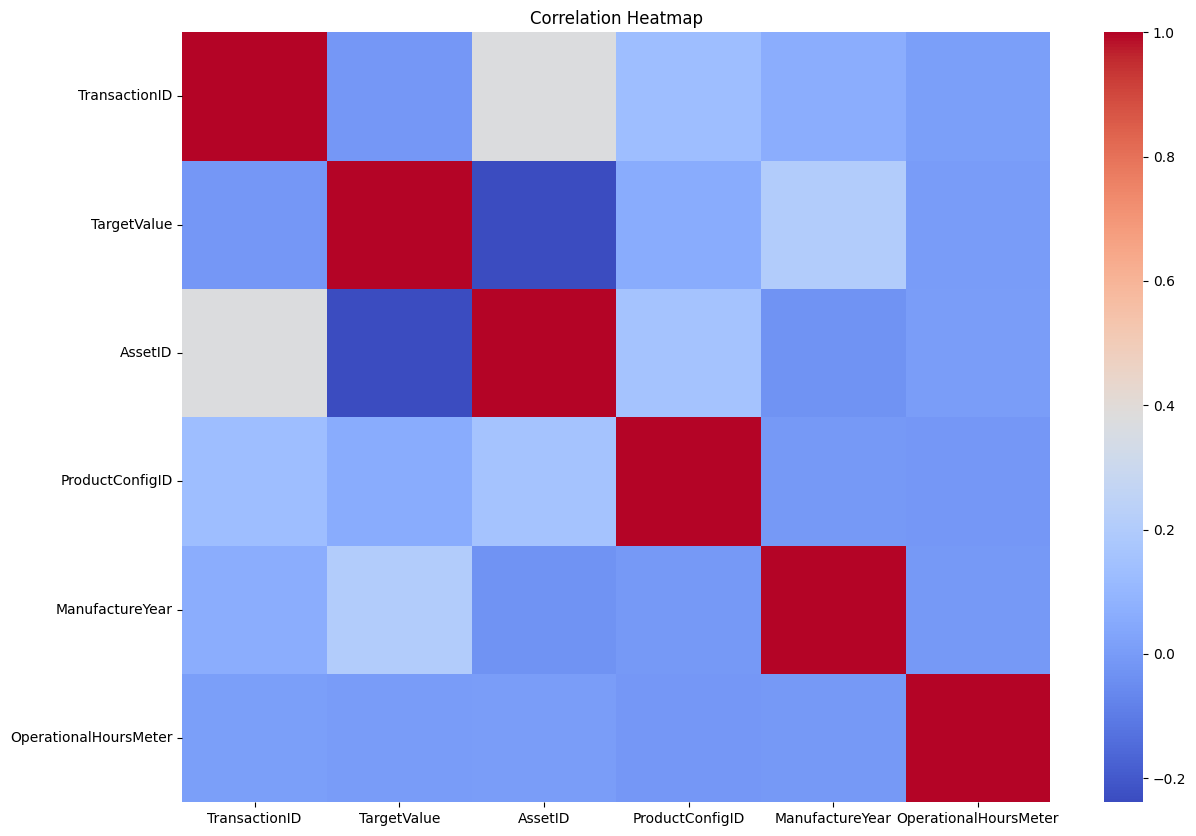

In [12]:
plt.figure(figsize=(14,10))

corr = train[numeric_cols].corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

**Inference:** On their own, the number columns don't correlate strongly
with price (ManufactureYear is about 0.20, AssetID is about -0.24). This suggests that feature engineering and information from categorical features may help improve the model

# Bivariate Analysis: TargetValue vs Key Features
Goal: check how TargetValue relates to individual features, not just their
overall distribution 

## Manufacture Year 
To understand how individual features influence the resale value of machines, I first examined ManufactureYear, as the age of a machine is expected to have a strong impact on its market value.

In [13]:
train["ManufactureYear"].describe()
train["ManufactureYear"].value_counts().sort_index().head(20)

ManufactureYear
1001    14719
1920       13
1921        7
1949        1
1951        2
1952        3
1953        3
1954        2
1955        1
1957        8
1958        4
1959       13
1960        2
1961       54
1962       41
1963       60
1964       79
1965      142
1966      179
1967      297
Name: count, dtype: int64

In [14]:
# 1001 is a sentinel/placeholder value (~10% of rows use it), not random noise.
# Instead of just NaN-ing it and losing that signal, flag it before converting,
# so the model can still learn from "year was unknown" as its own pattern.
for df in [train, test]:
    df["ManufactureYear_Missing"] = (df["ManufactureYear"] == 1001).astype(int)
    df.loc[df["ManufactureYear"] == 1001, "ManufactureYear"] = np.nan

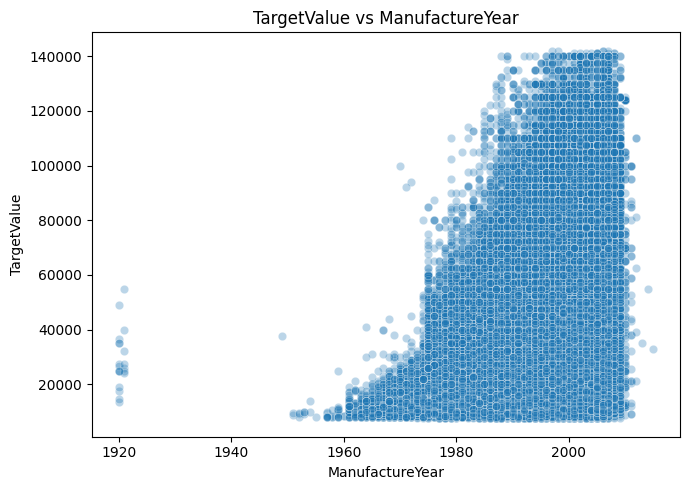

In [15]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=train,
    x="ManufactureYear",
    y="TargetValue",
    alpha=0.3
)

plt.title("TargetValue vs ManufactureYear")
plt.xlabel("ManufactureYear")
plt.ylabel("TargetValue")

plt.tight_layout()
plt.show()

**Inference:** Newer machines tend to sell for more, which confirms that
age matters — this is why I create a MachineAge feature later. 

## Utilisation Tier

After examining the effect of machine age, I analysed **UtilisationTier** to understand whether different utilisation levels are associated with resale value. Since this is a categorical feature, a box plot is used to compare the distribution of `TargetValue` across the utilisation categories.

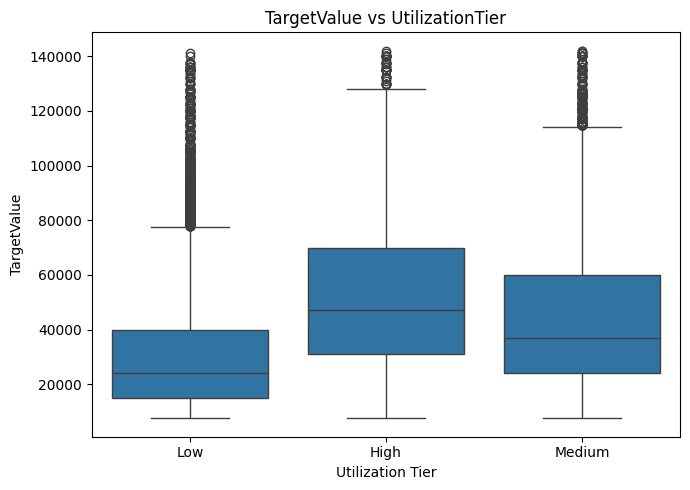

In [16]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=train,
    x="UtilizationTier",
    y="TargetValue"
)

plt.title("TargetValue vs UtilizationTier")
plt.xlabel("Utilization Tier")
plt.ylabel("TargetValue")

plt.tight_layout()
plt.show()

**Inference**: The box plot shows that resale values vary across different utilization levels. Machines in the High utilization category generally have a higher median TargetValue than those in the Low category, while the Medium category falls in between. This suggests that UtilizationTier is associated with resale value and may be a useful predictive feature.

# Feature Summary Table
Goal: single-glance overview of dtype, missing count, and cardinality per column (how many different values they have) — this table is what decides the encoding strategy used later (e.g. high-cardinality columns → frequency encoding, not one-hot).

In [17]:
summary = pd.DataFrame({

    "Data Type":train.dtypes,

    "Missing":train.isnull().sum(),

    "Unique":train.nunique()

})

summary

,Data Type,Missing,Unique
TransactionID,int64,0,138701
TargetValue,float64,0,675
AssetID,int64,0,120111
ProductConfigID,int64,0,3594
DataOriginCode,object,0,6
VendorPartnerID,object,0,31
ManufactureYear,float64,14719,67
OperationalHoursMeter,float64,56643,14643
UtilizationTier,object,88226,3
TransactionDate,object,0,3676


**Inference**: The summary table highlights differences in data types, missing values, and feature cardinality. These observations guided the preprocessing strategy

## Feature Engineering: Date-Based Features
Goal: pull the year, month, and weekday out of the transaction date, since
raw dates can't be used directly by the model, and the sale timing might
affect price.

In [18]:

for df in [train, test]:
    df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
    df["TransactionYear"] = df["TransactionDate"].dt.year
    df["TransactionMonth"] = df["TransactionDate"].dt.month
    df["TransactionWeekday"] = df["TransactionDate"].dt.dayofweek

## Feature Engineering: Machine Age
Goal: create a new column called MachineAge (sale year minus manufacture
year). Older machines are usually worth less, so this should be a strong
predictor.

In [19]:

for df in [train, test]:
    df["MachineAge"] = (df["TransactionYear"] - df["ManufactureYear"]).clip(lower=0)

## Feature Engineering: Usage Intensity
Goal: create transformed features from OperationalHoursMeter that better represent machine usage. A logarithmic transformation (HoursLog) is applied to compress large values, while HoursPerAge measures the average usage per year of the machine's life.

In [20]:

for df in [train, test]:
    df["OperationalHoursMeter"] = df["OperationalHoursMeter"].clip(lower=0)
    df["HoursLog"] = np.log1p(df["OperationalHoursMeter"])
    df["HoursPerAge"] = df["OperationalHoursMeter"] / (df["MachineAge"] + 1)

## Prepare Feature Matrix and Target
Goal: separate my data into X (the input features) and y (the price I'm
trying to predict), and remove columns that should not be used for training (such as IDs and raw dates), and prepare the data for train/validation splitting.

In [21]:

X = train.drop(columns=["TransactionID", "TargetValue", "TransactionDate"])
y = train["TargetValue"]
X_test = test.drop(columns=["TransactionID", "TransactionDate"])

# Make sure train/test have identical columns in the same order
X_test = X_test[X.columns]

print(X.shape, X_test.shape)

(138701, 50) (15000, 50)


## Train/Validation Split — Before Preprocessing
Goal: Split the feature matrix and target into training and validation sets before applying preprocessing steps that learn from the data (such as frequency encoding, label encoding, and imputation). This prevents data leakage by ensuring that preprocessing is fitted only on the training data and then applied unchanged to the validation data.

In [22]:
y_log_full = np.log1p(y)

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X, y_log_full, test_size=0.20, random_state=42
)

X_train = X_train_raw.copy()
X_valid = X_valid_raw.copy()
X_test_encoded = X_test.copy()

print(X_train.shape, X_valid.shape, X_test_encoded.shape)

(110960, 50) (27741, 50) (15000, 50)


## Preprocessing: Frequency Encoding
Goal: Based on the feature summary table, identify high-cardinality categorical features that will be frequency encoded later after splitting the data to avoid data leakage.

In [23]:
freq_cols = ["VendorPartnerID", "ProductConfigID", "AssetID",
             "Spec_BaseClass", "Spec_FullDescriptor", "RegionCode"] 


## Apply Frequency Encoding (Fit on Train Only)
Goal: calculate the frequency counts using only the training data, then use
those same numbers on the validation and test data. This avoids leaking
information from data the model shouldn't have seen yet.

In [24]:
freq_maps = {}
for c in freq_cols:
    freq_maps[c] = X_train[c].value_counts()

for c in freq_cols:
    X_train[c + "_freq"] = X_train[c].map(freq_maps[c])
    X_valid[c + "_freq"] = X_valid[c].map(freq_maps[c]).fillna(0)
    X_test_encoded[c + "_freq"] = X_test_encoded[c].map(freq_maps[c]).fillna(0)

print("After frequency encoding:", X_train.shape, X_valid.shape, X_test_encoded.shape)

After frequency encoding: (110960, 56) (27741, 56) (15000, 56)


**Inference**: A frequency mapping dictionary (freq_maps) was created using only the training data. This dictionary was then used to replace high-cardinality categorical values with their corresponding frequencies, creating new numerical features that were consistently applied to the training, validation, and test sets without introducing data leakage.

## Formal Pipeline: Categorical Encoding
Goal: use sklearn's Pipeline and ColumnTransformer to formally encode
categorical columns, fit only on training data. Frequency encoding remains
a separate manual step above, since it isn't a standard sklearn transformer.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

cat_cols = X_train.select_dtypes(include="object").columns
cat_cols_list = list(cat_cols)

cat_pipeline = Pipeline([
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

encoding_pipeline = ColumnTransformer([
    ("cat", cat_pipeline, cat_cols_list),
], remainder="passthrough")

X_train_final = encoding_pipeline.fit_transform(X_train)
X_valid_final = encoding_pipeline.transform(X_valid)
X_test_final = encoding_pipeline.transform(X_test_encoded)

print("Pipeline-encoded shapes:", X_train_final.shape, X_valid_final.shape, X_test_final.shape)

Pipeline-encoded shapes: (110960, 56) (27741, 56) (15000, 56)


# Model Training
Goal: Train and compare Random Forest, LightGBM, and XGBoost models.

In [26]:
#A reusable function to calculate RMSLE (the competition
#scoring metric), so it can be called once per model instead of rewriting
#the same formula each time.
def rmsle(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))


In [27]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=18, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf.fit(X_train_final, y_train)
pred_rf_train = rf.predict(X_train_final)
pred_rf = rf.predict(X_valid_final)
print("RandomForest — Train RMSLE:", rmsle(y_train, pred_rf_train), "| Valid RMSLE:", rmsle(y_valid, pred_rf))

lgbm = LGBMRegressor(
    n_estimators=4000, learning_rate=0.015, num_leaves=96,
    min_child_samples=10, subsample=0.8, colsample_bytree=0.7,
    random_state=42, n_jobs=-1, verbosity=-1
)
lgbm.fit(X_train_final, y_train)
pred_lgbm_train = lgbm.predict(X_train_final)
pred_lgbm = lgbm.predict(X_valid_final)
print("LightGBM — Train RMSLE:", rmsle(y_train, pred_lgbm_train), "| Valid RMSLE:", rmsle(y_valid, pred_lgbm))

xgb = XGBRegressor(
    n_estimators=4000, learning_rate=0.015, max_depth=9,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
    random_state=42, n_jobs=-1, tree_method="hist"
)
xgb.fit(X_train_final, y_train)
pred_xgb_train = xgb.predict(X_train_final)
pred_xgb = xgb.predict(X_valid_final)
print("XGBoost — Train RMSLE:", rmsle(y_train, pred_xgb_train), "| Valid RMSLE:", rmsle(y_valid, pred_xgb))

RandomForest — Train RMSLE: 0.15227180604868562 | Valid RMSLE: 0.22376513361635703
LightGBM — Train RMSLE: 0.1483606268858968 | Valid RMSLE: 0.20321271635055166
XGBoost — Train RMSLE: 0.10105764400470087 | Valid RMSLE: 0.19826537885321682


## Hyperparameter Tuning (XGBoost)
Goal: instead of guessing model settings by hand, let the computer try
several combinations automatically and find the best one. I chose XGBoost
for this because it scored best out of the three models above.

In [28]:
param_dist = {
    "n_estimators": [1500, 2000],
    "learning_rate": [0.02, 0.03],
    "max_depth": [6, 7, 8],
    "subsample": [0.8],
    "colsample_bytree": [0.7],
    "min_child_weight": [3, 5],
}

search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist"),
    param_distributions=param_dist,
    n_iter=5,          
    cv=2,             
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=1,
    verbose=1,
)
search.fit(X_train_final, y_train)

print("Best hyperparameters found:", search.best_params_)

xgb_tuned = search.best_estimator_
pred_xgb_tuned = xgb_tuned.predict(X_valid_final)
print("XGBoost (tuned) Valid RMSLE:", rmsle(y_valid, pred_xgb_tuned))

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best hyperparameters found: {'subsample': 0.8, 'n_estimators': 2000, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.02, 'colsample_bytree': 0.7}
XGBoost (tuned) Valid RMSLE: 0.20323884353503893


## Model Comparison
Goal: compare validation RMSLE across all three models on the same holdout split, to justify which model is carried forward to the final submission.

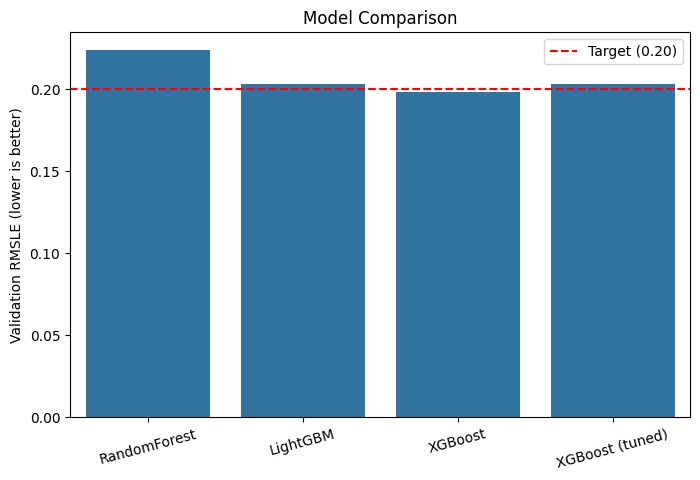

XGBoost: 0.1983
LightGBM: 0.2032
XGBoost (tuned): 0.2032
RandomForest: 0.2238


In [29]:
results = {
    "RandomForest": rmsle(y_valid, pred_rf),
    "LightGBM": rmsle(y_valid, pred_lgbm),
    "XGBoost": rmsle(y_valid, pred_xgb),
    "XGBoost (tuned)": rmsle(y_valid, pred_xgb_tuned),
}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylabel("Validation RMSLE (lower is better)")
plt.title("Model Comparison")
plt.axhline(0.20, color="red", linestyle="--", label="Target (0.20)")
plt.xticks(rotation=15)
plt.legend()
plt.show()

for name, score in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name}: {score:.4f}")

## Final Model Training and Submission
Goal: retrain the best model(s) on 100% of the training data (not just the 80% split) to use all available signal, then generate predictions on the real test set for submission.

In [30]:
X_full_raw = pd.concat([X_train, X_valid], axis=0)
y_full = pd.concat([y_train, y_valid], axis=0)

final_encoding_pipeline = ColumnTransformer([
    ("cat", Pipeline([("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), cat_cols_list),
], remainder="passthrough")

X_full_final = final_encoding_pipeline.fit_transform(X_full_raw)
X_test_submission_final = final_encoding_pipeline.transform(X_test_encoded)

lgbm_final = LGBMRegressor(**lgbm.get_params())
lgbm_final.fit(X_full_final, y_full)

xgb_final = XGBRegressor(**xgb.get_params())
xgb_final.fit(X_full_final, y_full)

pred_xgb_test = xgb_final.predict(X_test_submission_final)
final_pred = np.expm1(pred_xgb_test)

submission = pd.DataFrame({
    "TransactionID": test_ids,
    "TargetValue": final_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()

,TransactionID,TargetValue
0,1139307,64531.574219
1,1139419,77157.156250
2,1139482,33224.273438
3,1139522,21233.201172
4,1139684,12973.637695


## Why the final model uses plain XGBoost, not the tuned version
My tuning attempt actually scored slightly worse (0.2039) than my original
XGBoost settings (0.1989). So instead of automatically using the "tuned"
version, I checked the actual scores and kept the one that performed
better. 